# **EDA**

In [1]:
import torch
import torchvision
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm.auto import tqdm

# Tải Caltech-256 (Khoảng 1.2GB, Colab tải sẽ mất một chút thời gian)
# Lưu ý: Tham số download=True sẽ tự động tải và giải nén
dataset = datasets.Caltech256(root='./data', download=True)

print(f"Dataset size: {len(dataset)} images")
print(f"Number of classes: {len(dataset.categories)}")

100%|██████████| 1.18G/1.18G [00:41<00:00, 28.3MB/s]


Dataset size: 30607 images
Number of classes: 257


Visualize a number of random image in the dataset

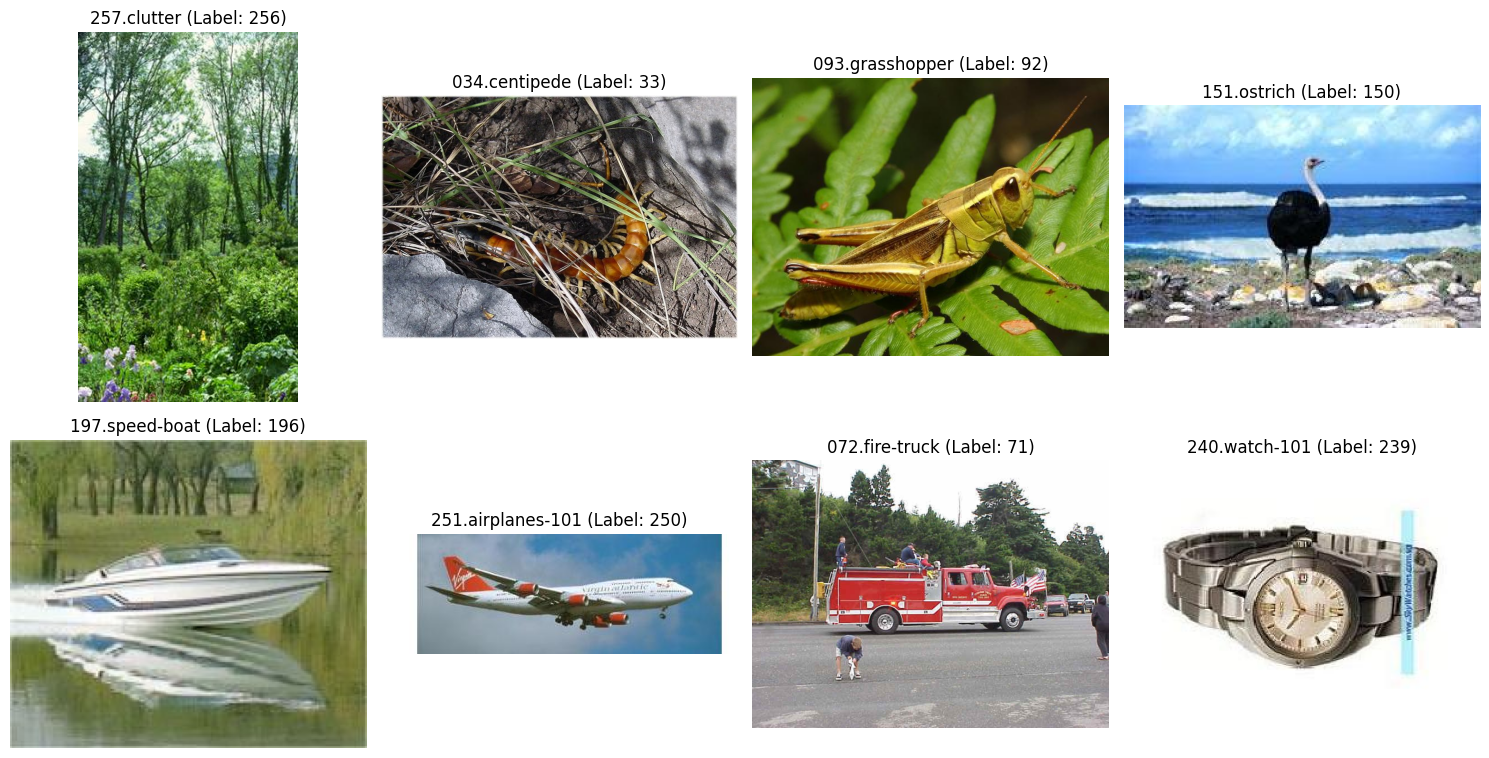

In [2]:
import random

# Lấy ngẫu nhiên 8 ảnh để hiển thị
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i in range(8):
    # Chọn random 1 index trong tập dữ liệu
    idx = random.randint(0, len(dataset) - 1)
    img, label_idx = dataset[idx]

    # Lấy tên class tương ứng
    class_name = dataset.categories[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(f"{class_name} (Label: {label_idx})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Dataset distribution

Top 5 classes with most images:
- 257.clutter: 827 images
- 251.airplanes-101: 800 images
- 145.motorbikes-101: 798 images
- 253.faces-easy-101: 435 images
- 232.t-shirt: 358 images

Top 5 classes with least images:
- 086.golden-gate-bridge: 80 images
- 099.harpsichord: 80 images
- 179.scorpion-101: 80 images
- 204.sunflower-101: 80 images
- 223.top-hat: 80 images


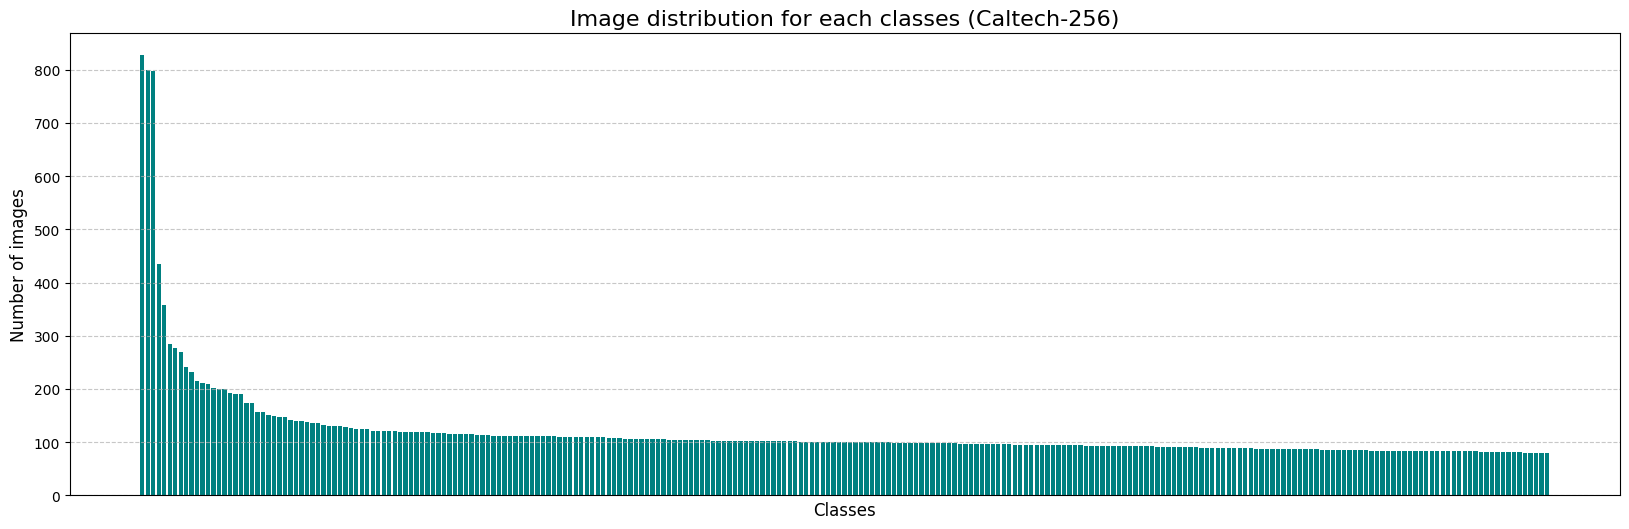

In [3]:
# Đếm số lượng ảnh trong mỗi class
class_counts = Counter([dataset.categories[label] for _, label in dataset])

# Sắp xếp để vẽ biểu đồ cho đẹp (từ cao xuống thấp)
sorted_counts = class_counts.most_common()
classes = [item[0] for item in sorted_counts]
counts = [item[1] for item in sorted_counts]

plt.figure(figsize=(20, 6))
plt.bar(classes, counts, color='teal')
plt.title('Image distribution for each classes (Caltech-256)', fontsize=16)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.xticks([]) # Ẩn label trục x vì 257 classes quá dài
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị Top 5 class nhiều nhất và ít nhất
print("Top 5 classes with most images:")
for c, count in sorted_counts[:5]:
    print(f"- {c}: {count} images")

print("\nTop 5 classes with least images:")
for c, count in sorted_counts[-5:]:
    print(f"- {c}: {count} images")

plt.show()

Image size analyzing

Analyzing...


  0%|          | 0/30607 [00:00<?, ?it/s]

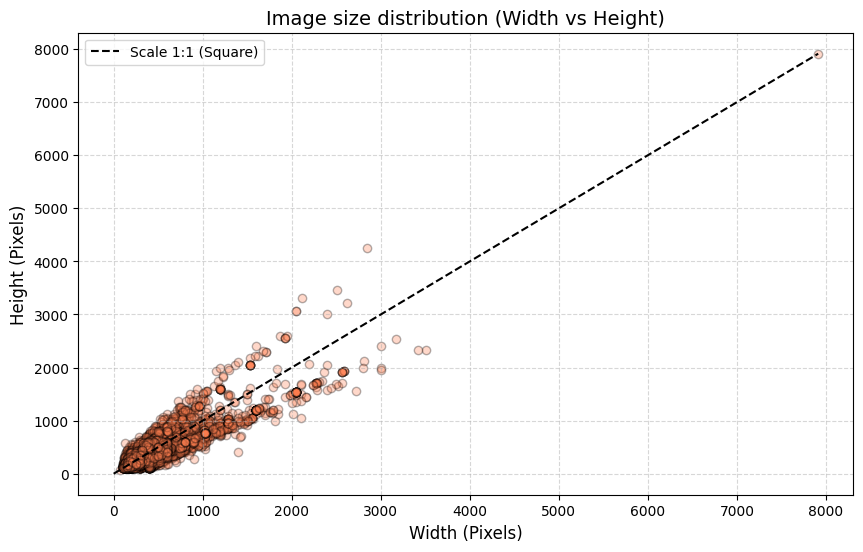

Average width: 371.24 px
Average height: 325.97 px


In [4]:
widths = []
heights = []

# Quét qua dataset để lấy kích thước (Dùng tqdm để hiển thị thanh tiến trình)
print("Analyzing...")
for img, _ in tqdm(dataset):
    w, h = img.size
    widths.append(w)
    heights.append(h)

# Vẽ Scatter plot phân bố kích thước
plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.3, color='coral', edgecolors='k')
plt.title('Image size distribution (Width vs Height)', fontsize=14)
plt.xlabel('Width (Pixels)', fontsize=12)
plt.ylabel('Height (Pixels)', fontsize=12)

# Vẽ thêm đường chéo tỷ lệ 1:1 để tham chiếu
max_val = max(max(widths), max(heights))
plt.plot([0, max_val], [0, max_val], 'k--', label='Scale 1:1 (Square)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Average width: {np.mean(widths):.2f} px")
print(f"Average height: {np.mean(heights):.2f} px")

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np

IMG_SIZE = 224

# 1. Định nghĩa lại Transforms (Thêm dòng convert RGB lên đầu)
train_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')), # ÉP CHUYỂN THÀNH ẢNH MÀU RGB
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')), # ÉP CHUYỂN THÀNH ẢNH MÀU RGB
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Class Wrapper giờ đã gọn gàng hơn nhiều
class Caltech256Wrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# 3. Chia tập dữ liệu (vẫn giữ nguyên seed=42 để đảm bảo kết quả)
full_dataset = datasets.Caltech256(root='./data', download=False)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_sub, val_sub, test_sub = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

train_dataset = Caltech256Wrapper(train_sub, transform=train_transforms)
val_dataset = Caltech256Wrapper(val_sub, transform=test_transforms)
test_dataset = Caltech256Wrapper(test_sub, transform=test_transforms)

# 4. DataLoader
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Successfully update dataloader!")

Successfully update dataloader!


Training and Evalutation

In [6]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đã bổ sung tham số model_name="model" ở cuối
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, model_name="model"):
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    best_val_loss = float('inf') # Khởi tạo loss tốt nhất là vô cực

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # --- VALIDATING ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Validating"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_acc)
        history['val_f1'].append(epoch_f1)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"Val Accuracy: {epoch_acc:.4f} | Val F1-Score: {epoch_f1:.4f}")

        # --- MODEL CHECKPOINTING ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), f"{model_name}_best.pth")
            print(f"--> File saved {model_name}_best.pth (Val Loss: {best_val_loss:.4f})")
        else:
            print(f"--> Val Loss not decreasing.")

    return model, history

In [7]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# Hàm Loss chung cho cả 2 model (Phân loại đa lớp)
criterion = nn.CrossEntropyLoss()
# Số epochs chạy thử (Bạn có thể tăng lên 10-15 sau khi test thành công)
EPOCHS = 10

# ==========================================
# 1. KHỞI ĐỘNG VÀ HUẤN LUYỆN CNN (RESNET50)
# ==========================================
print("--- KHỞI TẠO RESNET50 ---")
# Tải mô hình đã được pre-trained trên ImageNet
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Bẻ gãy lớp cuối cùng (1000 classes của ImageNet) và thay bằng 257 classes của ta
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 257)

# Khởi tạo thuật toán tối ưu với Learning Rate nhỏ (1e-4) để fine-tune
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=1e-4)

print("Bắt đầu train ResNet50...")
resnet_model, resnet_history = train_and_evaluate(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_resnet,
    num_epochs=10,
    model_name="resnet50" # <-- CHÌA KHÓA Ở ĐÂY: Ép nó lưu thành resnet50_best.pth
)

# ==========================================
# 2. KHỞI ĐỘNG VÀ HUẤN LUYỆN ViT (ViT-B_16)
# ==========================================
print("\n--- KHỞI TẠO VISION TRANSFORMER (ViT-B_16) ---")
# Tải mô hình ViT pre-trained
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# Cấu trúc của ViT hơi khác CNN, lớp cuối cùng nằm ở biến 'heads.head'
num_ftrs_vit = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_ftrs_vit, 257)

optimizer_vit = optim.Adam(vit_model.parameters(), lr=1e-4)

print("\nBắt đầu train ViT-B_16...")
vit_model, vit_history = train_and_evaluate(
    model=vit_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_vit,
    num_epochs=10,
    model_name="vit_b_16" # <-- CHÌA KHÓA Ở ĐÂY: Ép nó lưu thành vit_b_16_best.pth
)

--- KHỞI TẠO RESNET50 ---
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


Bắt đầu train ResNet50...

Epoch 1/10
--------------------


Training:   0%|          | 0/335 [00:00<?, ?it/s]

Validating:   0%|          | 0/72 [00:00<?, ?it/s]

...

Train Loss: 0.1250 | Val Loss: 0.6719
Val Accuracy: 0.8482 | Val F1-Score: 0.8327
--> Val Loss not decreasing.

Epoch 10/10
--------------------


Training:   0%|          | 0/335 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c940586fd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c940586fd80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validating:   0%|          | 0/72 [00:00<?, ?it/s]

Train Loss: 0.1169 | Val Loss: 0.6686
Val Accuracy: 0.8499 | Val F1-Score: 0.8340
--> Val Loss not decreasing.


Comparison

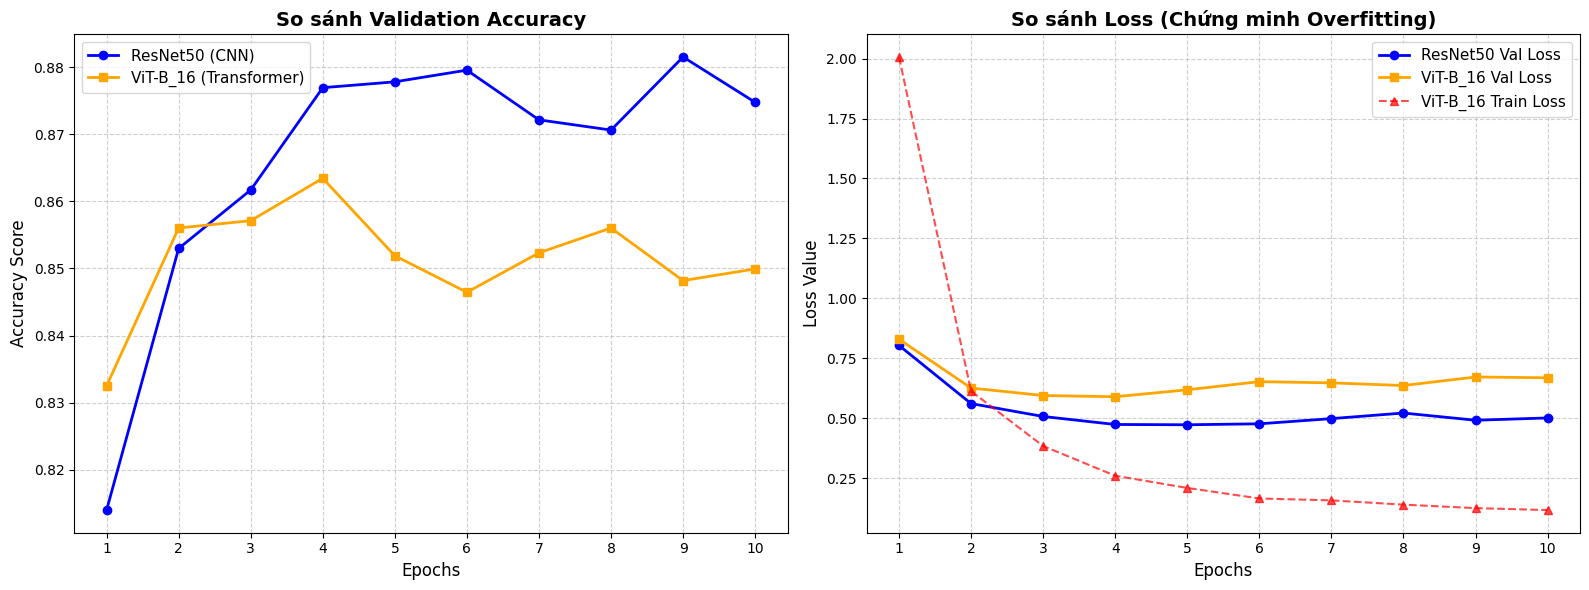

In [8]:
import matplotlib.pyplot as plt

# Lấy số lượng epoch thực tế đã chạy
epochs = range(1, len(resnet_history['train_loss']) + 1)

# Cài đặt kích thước khung hình
plt.figure(figsize=(16, 6))

# --- BIỂU ĐỒ 1: SO SÁNH ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(epochs, resnet_history['val_acc'], label='ResNet50 (CNN)', marker='o', color='blue', linewidth=2)
plt.plot(epochs, vit_history['val_acc'], label='ViT-B_16 (Transformer)', marker='s', color='orange', linewidth=2)
plt.title('So sánh Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# --- BIỂU ĐỒ 2: SO SÁNH LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs, resnet_history['val_loss'], label='ResNet50 Val Loss', marker='o', color='blue', linewidth=2)
plt.plot(epochs, vit_history['val_loss'], label='ViT-B_16 Val Loss', marker='s', color='orange', linewidth=2)
# Vẽ thêm Train Loss của ViT để chứng minh nó bị Overfitting
plt.plot(epochs, vit_history['train_loss'], label='ViT-B_16 Train Loss', marker='^', color='red', linestyle='--', alpha=0.7)

plt.title('So sánh Loss (Chứng minh Overfitting)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
# Chạy trên Colab để sinh ra file text chứa tên 257 classes
with open('categories.txt', 'w') as f:
    for cat in dataset.categories:
        f.write(f"{cat}\n")
print("Đã tạo xong file categories.txt, hãy tải về máy!")

Đã tạo xong file categories.txt, hãy tải về máy!
